OCR 라이브러리가 이미지 속 글자를 얼마나 잘 읽어내는지 직접 확인해 봅시다.
`data` 폴더에 있는 이미지 5장을 하나씩 넣어보면서, 어떤 이미지는 잘 읽히고 어떤 이미지는 안 읽히는지 비교해 볼게요.

이 실습은 `pip install easyocr` 한 줄만 설치하면 진행할 수 있어요. 처음 코드를 실행할 때 언어 인식 모델을 자동으로 내려받으니 인터넷 연결이 필요하고, 한 번 받으면 이후엔 저장된 모델을 재사용해요.

In [1]:
!pip install easyocr

  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 33.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 4.1/4.1 MB 49.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---- ----------------------------------- 12.3/122.1 MB 55.1 MB/s eta 0:00:02
   -------- ------------------------------- 24.6/122.1 MB 57.8 MB/s eta 0:00:02
   ------------ --------------------------- 36.7/122.1 MB 56.9 MB/s eta 0:00:02
   --------------- ------------------------ 48.8/122.1 MB 56.5 MB/s eta 0:00:02
   -------------------- ------------------- 61.3/122.1 MB 56.7 MB/s eta 0:00:02
   ------------------------ --------------- 73.7/122.1 MB 57.3 MB/s eta 0:00:01
   ---------------------------- ----------- 85.7/122.1 MB 57.0 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# 이미지 속 글자를 읽기 위한 라이브러리를 불러옵니다.
import numpy as np
import easyocr
from PIL import Image

# 이 `reader`는 뒤에서 이미지를 읽을 때마다 계속 재사용할 예정입니다!
# gpu=False : 그래픽카드 없이 CPU로 동작하도록 설정합니다.
reader = easyocr.Reader(["ko", "en"], gpu=False)

# 이 실습에서 사용할 이미지들이 들어있는 폴더입니다. 뒤에서 계속 사용할 예정입니다!
data_dir = "data"


# 윈도우에서는 파일 경로에 한글이 들어있으면 easyocr가 이미지를 열지 못해요.
# 그래서 이미지를 먼저 열어 숫자 배열로 바꿔주는 함수를 만들어 둡니다. 이것도 계속 재사용할 예정입니다!
def read_image(path):
    return np.array(Image.open(path).convert("RGB"))

Using CPU. Note: This module is much faster with a GPU.
c:\Users\rando\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


먼저 가장 깔끔한 이미지부터 읽어봅시다. `키키테크_가격표.png`는 표 형태로 정리된 인쇄 문서예요.

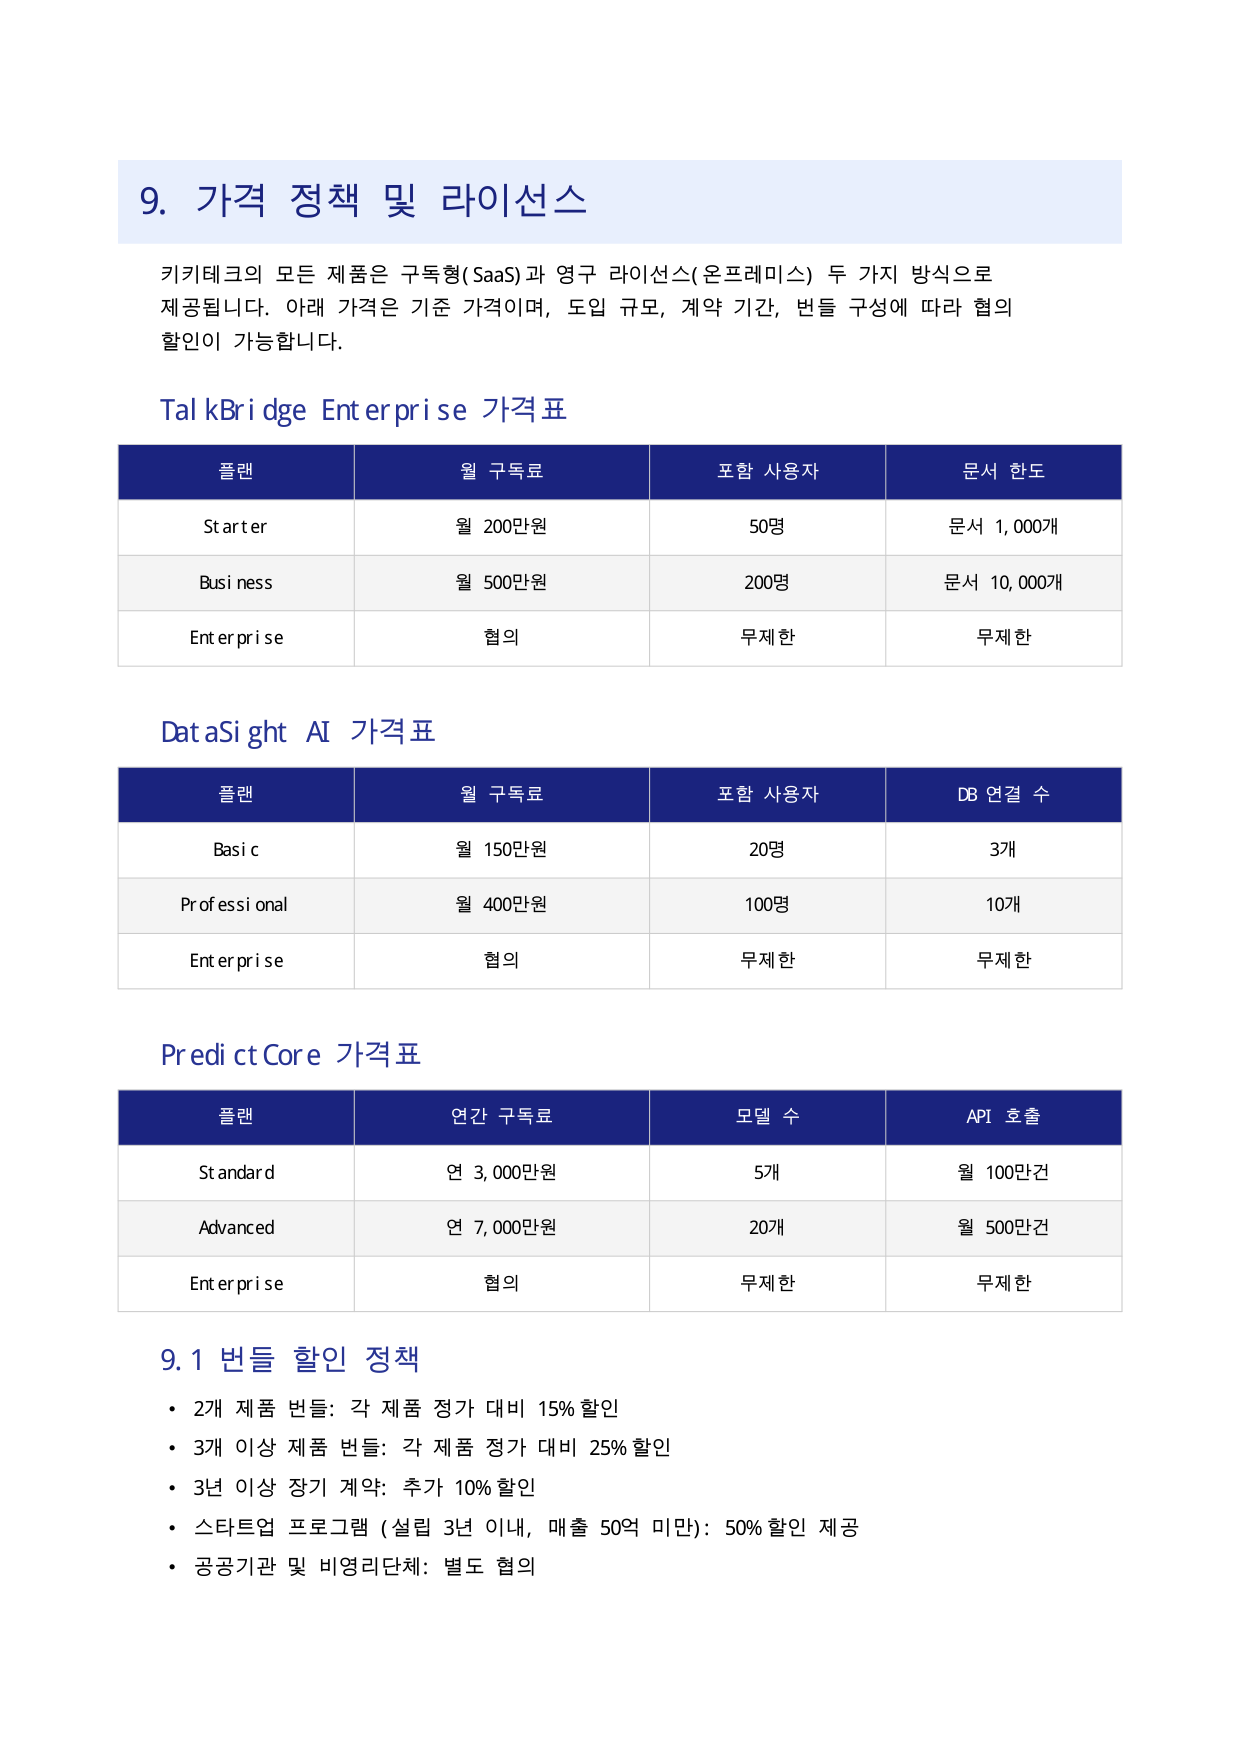

In [3]:
# 이 `image` 변수는 바로 다음 셀에서 이어서 사용할 예정입니다!
image = Image.open(f"{data_dir}/키키테크_가격표.png")
image

이미지를 `reader.readtext()`에 넣으면 이미지 속 글자만 텍스트로 뽑아낼 수 있어요.

In [2]:
# detail=0 : 글자 위치·정확도 없이 텍스트만 받습니다.
# paragraph=True : 가까이 있는 글자끼리 묶어서 문단처럼 정리해줍니다.
result = reader.readtext(read_image(f"{data_dir}/키키테크_가격표.png"), detail=0, paragraph=True)

print("\n".join(result))

c:\Users\rando\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


9 가격   정책 및 라이선스
키키터 크의 모든 제품은 구독형( SaaS) 과 영구 라이선스(온프레미스) 두 가지 방식으로 제공되니다. 아래   가격은 기준 가격이려, 도입 규모 계약 기간; 번들  구성에  따라 협의 할인이   가능합니다.
Tal kBri dge Enterprise 가격표
플랜
월 구독료
포함  사용자
문서 한도
Starter
월 200만원
50명
문서   1, OO0개
Busi ness
월 500만원
200명
문서   10, OOO개
Enterprise
협의
무제한
무제한
DataSi ght A 가격표
플랜
월 구독료
포함  사용자
DB 연결 수
Basi c
월  150만원
20명
3개
Prof essi onal
월 400만원
100명
10개
Enterprise
협의
무제한
무제한
Predi ctCore 가격표
플랜
연간 구독료
모델 수
API 호출
Standard
연 3 000만원
5개
월 100만건
Advanced
7, 000만원
20개
월 500만건
Enterprise
협의
무제한
무제한
9. 1 번들  할인 정책 2개 제품 번들: 각 제품 정가 대비 159 할인 3개 이상 제품 번들: 각 제품 정가 대비 25% 할인 3년 이상 장기 계약:   추가 109 할인 스타트업 프로그램 (설립 3년 이내, 매출 50억 미만) : 509 할인  제공 공공기관 및 비영리단체:  별도 협의


원본은 표였는데, 결과는 줄과 칸 구분 없이 글자만 순서대로 나열된 걸 확인할 수 있어요. 표의 '구조'는 인식하지 못하고 '글자'만 읽어낸 거예요.

이번엔 조금 더 어려운 이미지로 넘어가 봅시다. `영수증_이미지.jpg`는 글자 크기가 작고, 점선이나 특수문자가 섞여 있어요.

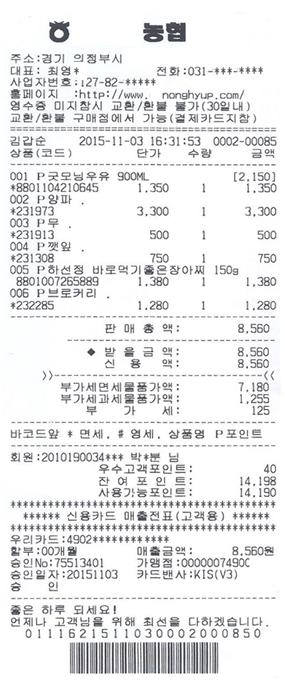

In [3]:
image = Image.open(f"{data_dir}/영수증_이미지.jpg")
image

In [4]:
result = reader.readtext(read_image(f"{data_dir}/영수증_이미지.jpg"), detail=0, paragraph=True)

print("\n".join(result))

5 농협 주소 :김기 의정부시 대표 전화 :031-+++-++++ {품하볼염:hztsgar -*++*+ 데이 ;상X: 교물 @ nonghyun com/ 입수 3 미지 교망 가 ( 30입내 ) 구야정에 서 {슬물( 제카드지장 ) 감감스 2015-]1-03 16:31 :53 00D2-00055 상울 (코드 ) 단가 수량 0O1 조모님우유 9D0n [2. 150] *8831104210645 350 ,330 002 임파 4231973 3,300 3,300 003 1'다 *231913 500 500 004 꼬임 *231308 750 750 0U5 하선정 바로먹기 온장아씨 1ED3 5801007255839 ,3B0 380 006 로커리 *232285 230 280 만 매 560 올 금 560 찬 560 > )- 부가세품세m물가역= IBD 255 125 바코드앞 면세 임세 상품명 P모입트 회원 :2010190334+*+ 박구난 우수고각 모인트 잔 여 인 트 1드3 사용가 능포인트 J5J +>4 + + ++V 신용카드 매#전표 (고려8 ) 4+4++주4++ ++4+++++++++++ 우리카드 4902+* :OD개 얘소금액 550권 승인No:75513401 :0000007493C 승인입자 :20151103 카을천 ;034030V39C
은 하루 되체요 언장난 , '{고경블 {5 위해0 3승하0 달하경숨님당


앞의 표보다 글자 크기가 작아서, 자릿수가 밀리거나 엉뚱한 문자로 잘못 읽힌 부분이 군데군데 보일 거예요.

이번엔 숫자가 빼곡한 통계표, `표_이미지.png`를 읽어봅시다.

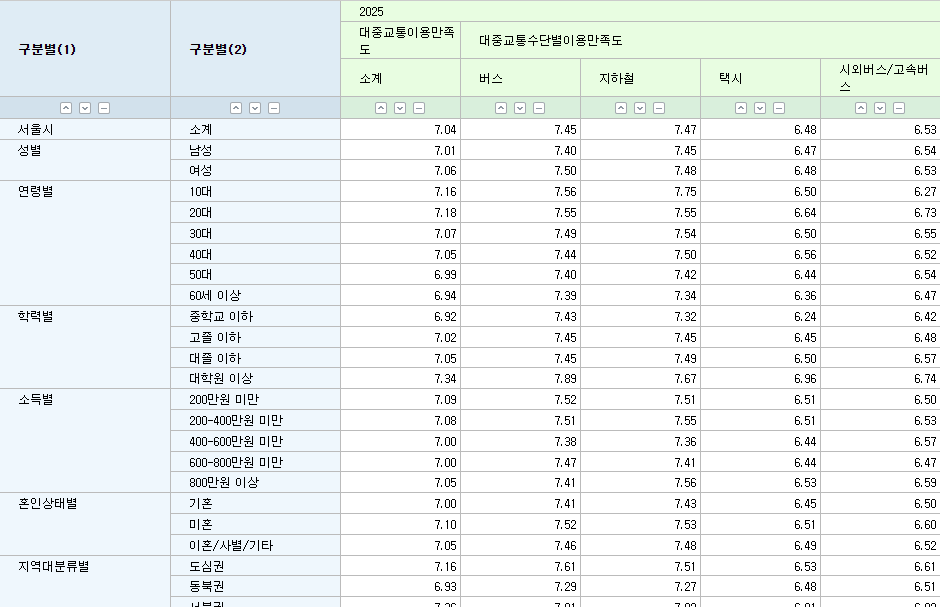

In [5]:
image = Image.open(f"{data_dir}/표_이미지.png")
image

In [6]:
result = reader.readtext(read_image(f"{data_dir}/표_이미지.png"), detail=0, paragraph=True)

print("\n".join(result))

225 대중교통미용만족
대중교통수단별미용만족도
구분별(1)
구분별 (2)
시외버스 고속버
소계
버스
지하철
[E 7,U4
서물시 섬별
소계 남성 여성 1때 2때대 3대 4때 5대
7,47
연령별
GII세 미상 중학교 미하 고꼴 미하 대꼴 이하 대학원 미상 2만원 미만 2-4미만원 미만 4DD-E이만원 미만 GOO-8이만만원 미만 8마만원 미상 기촌 미혼 미혼 / 사별/기타 도심권 동북권
학력별
소득별
741
혼인상태별
지역대분류별
7,61
7,51
7,27


숫자와 항목이 뒤섞여서, 어떤 숫자가 어떤 항목·연도에 해당하는 값인지 텍스트만으로는 다시 알아보기 어려워요. 표의 칸 구조가 사라지면 숫자 데이터는 사실상 못 쓰게 되는 셈이에요.

이제 가장 어려운 이미지, 손글씨 `손글씨.jpg`를 읽어봅시다. 사람도 한 번에 읽기 쉽지 않은 흘림체예요.

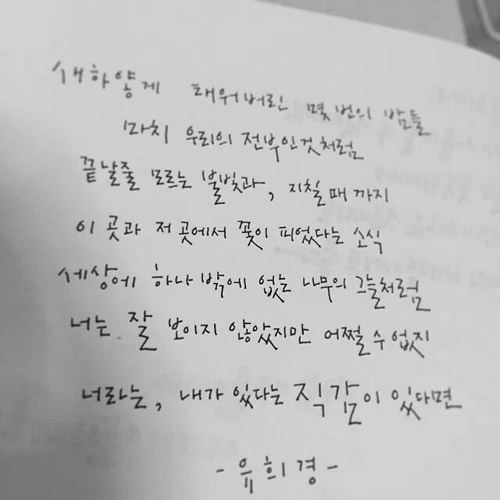

In [7]:
image = Image.open(f"{data_dir}/손글씨.jpg")
image

In [8]:
result = reader.readtext(read_image(f"{data_dir}/손글씨.jpg"), detail=0, paragraph=True)

print("\n".join(result))

시서하" 트 승계 대우1 4A3! 몇 '선'리 '지 "n 우리의 전부인것처널 끝날출 모로는 ''불"러과, 지모 때 까지 6 1 곳과 저 곳어서 꽃인 피없다는 소식 세상 하나 낮낭에 없 나무리 '슬내럼 너는 자 ' 단지 양있지안 어절수없' 너른늘 , 내H가 잇다는 직가이 X 사다면 '
91 겨


결과가 거의 알아볼 수 없는 문자들로 나왔을 거예요. OCR은 정해진 글자 모양을 기준으로 학습되기 때문에, 사람마다 제각각인 손글씨는 특히 취약해요.

마지막으로 `GDP_그래프.jpg`, 막대그래프 형태의 인포그래픽을 읽어봅시다.

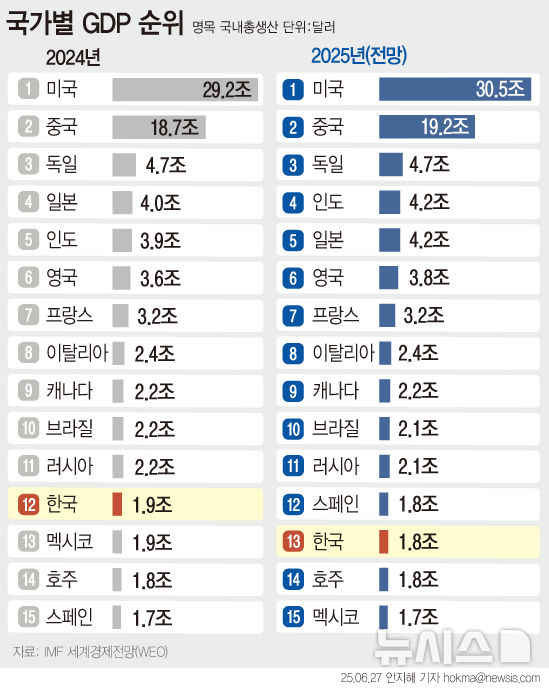

In [9]:
image = Image.open(f"{data_dir}/GDP_그래프.jpg")
image

In [10]:
result = reader.readtext(read_image(f"{data_dir}/GDP_그래프.jpg"), detail=0, paragraph=True)

print("\n".join(result))

국가별 GDP 순위 명목 국니중생산 단위:달러 2024년 2025년전망) 미국 29.2조 미국 30.5조 중국 18.7조 0 중국 19.2 독일 4.7조 독일 4.7조 일본 4.0조 인도 4.2조 인도 3.9조 일본 4.2조 영국 3.6조 영국 3.8조 프랑스 3.2조 프랑스 3.2조 이달리아 2.4조 이달리아 2.4조 캐나다 2.2조 캐나다 2,2조 브라질 2.2조 브라질 2.1조 러시야 2.2조 러시야 2.1조 한국 1.9조 스페인 1,8조 맥시코 1.9조 한국 1.8조 호주 1.8조 호주 1.8조 스인 1.7조 댁시코 17조 지붕 I바 세계경제진망 W=O MIy 2305.27 안지하 기자 hckrraoriewsis com


나라 이름과 숫자는 띄엄띄엄 읽히지만, "어느 나라가 몇 위인지", "막대가 어떻게 늘어났는지" 같은 그림 전체의 의미는 전혀 담겨있지 않아요. OCR은 글자를 읽을 뿐, 그림을 이해하진 못하기 때문이에요.

지금까지는 이미지를 한 장씩 확인했는데, 실무에서는 이미지가 수십, 수백 장일 수도 있어요. 이럴 땐 반복문으로 폴더 안 이미지를 한 번에 처리할 수 있습니다.

In [15]:
import os

results = [] # 각 이미지의 OCR 결과를 이 리스트에 순서대로 쌓습니다. 뒤에서 표로 정리할 때 사용해요!

for filename in os.listdir(data_dir):
    text_list = reader.readtext(read_image(f"{data_dir}/{filename}"), detail=0, paragraph=True)
    text = "\n".join(text_list)
    results.append({"파일명": filename, "인식된_글자수": len(text.strip()), "추출된 텍스트": text})

    print(f"{filename} : {len(text.strip())}자 인식됨")

c:\Users\rando\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


GDP_그래프.jpg : 354자 인식됨
손글씨.jpg : 163자 인식됨
영수증_이미지.jpg : 674자 인식됨
키키테크_가격표.png : 682자 인식됨
표_이미지.png : 257자 인식됨


결과를 저장해 봅시다.

In [16]:
# 결과를 담아둘 폴더를 만듭니다. 이미 있으면 그냥 넘어갑니다.
os.makedirs("output", exist_ok=True)

# results 안에 쌓아둔 결과를 하나씩 꺼내서, 이미지 이름과 똑같은 txt 파일로 저장합니다.
for result in results:
    filename = os.path.splitext(result["파일명"])[0]  # "표_이미지.png" -> "표_이미지"
    save_dir = f"output/{filename}.txt"

    with open(save_dir, "w", encoding="utf-8") as f:
        f.write(result["추출된 텍스트"])

    print(f"{save_dir} 저장 완료")

output/GDP_그래프.txt 저장 완료
output/손글씨.txt 저장 완료
output/영수증_이미지.txt 저장 완료
output/키키테크_가격표.txt 저장 완료
output/표_이미지.txt 저장 완료


이번에 활용한 EasyORC는 API키가 필요 없고, pip install 만으로도 설치가 가능하기 때문에 활용 했습니다.

무료 ocr 모델은 이정도 한계가 있고, 더 좋은 성능의 ocr 모델들을 활용하고 싶다면 네이버 클로바 OCR이나 Upstage의 OCR api 서비스를 활용하는 것이 좋습니다. (물론 api 서비스기 때문에 보안 취약점은 발생 가능합니다.)